In [29]:
import numpy as np
import matplotlib.pyplot as plt
import util
import nd2
import os

exp = '20250502'
culture = 'culture3'
trial = 'trial0'

trial_subpath = f'{exp}/{culture}/{trial}'
# local_data_dir = 'D:\\User\\AG_Dean\\Hana_Sheldon'
local_data_dir = './data'
remote_data_dir = '/home/khzstimpi/data'

trial_dir = os.path.join(local_data_dir,trial_subpath)
if not os.path.exists(os.path.join(trial_dir, 'sample.bin')):
    os.system(f'scp -r khzstimpi@khzstimpi:{remote_data_dir}/{trial_subpath}/* {trial_dir}')

    
print('Loading electric field data')
efield, sample_times, frame_times, settings = util.load_stim_data(trial_dir, subsampling_factor=32)

mod_period = 1.0/settings['mod_frequency']        
mod_periods_per_block = int(np.ceil(settings['block_duration']/mod_period))
    
t = float(settings['nostim_pre_post_duration'])
pulse_times = []
for phase in settings['phases']:
    t_pulse = t + (mod_periods_per_block-1) * mod_period + mod_period*phase/360
    pulse_times.append(t_pulse)
    t += mod_periods_per_block * mod_period + settings['nostim_interblock_duration']
pulse_times = np.array(pulse_times)
phases = settings['phases']
pamps = settings['pamps']

print('Loading microscopy data')
raw = nd2.imread(trial_dir + '/raw.nd2')
frame_rate = 1.0/np.median(np.diff(frame_times))
print(f'Loaded video with size {raw.shape} and a frame rate = {frame_rate:0.2f} Hz')

Loading electric field data
Loading microscopy data
Loaded video with size (4200, 600, 600) and a frame rate = 9.99 Hz


In [30]:
window_length_post_pulse = 3
window_length_pre_pulse = 3

frames_post_pulse = int(np.ceil(window_length_post_pulse*frame_rate))
frames_pre_pulse = int(np.ceil(window_length_pre_pulse*frame_rate))

pulse_windows = []
for t in pulse_times:
    pulse_index = np.argmin(np.abs(frame_times-t))
    window = raw[pulse_index-frames_pre_pulse : pulse_index+frames_post_pulse]
    pulse_windows.append(window)
pulse_windows = np.array(pulse_windows)

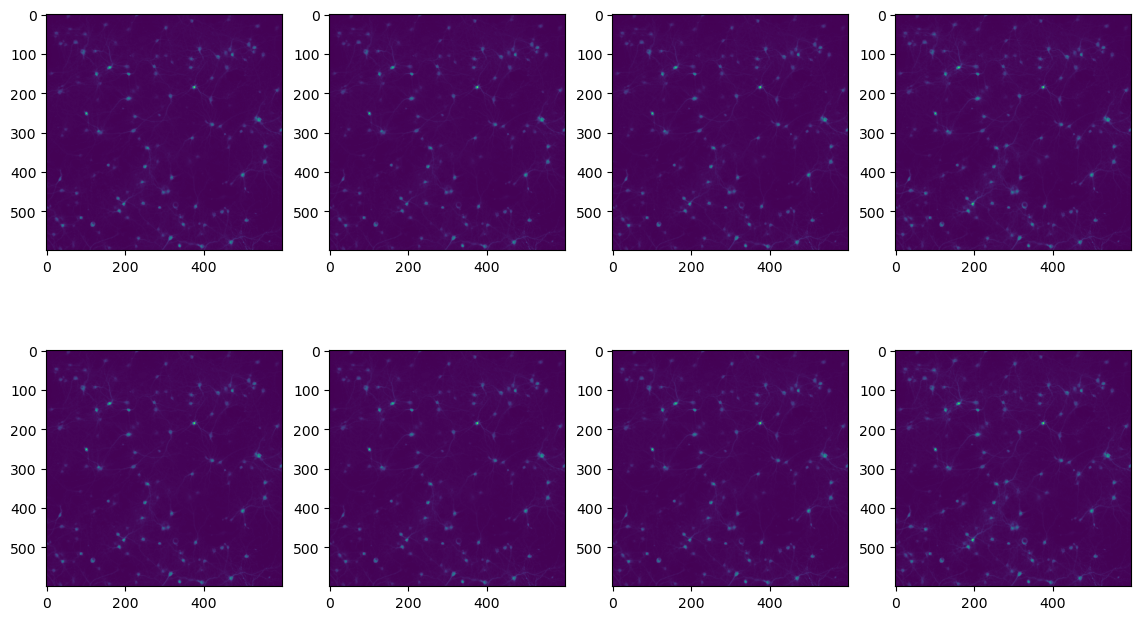

In [32]:
fig = plt.figure(figsize=(14,8))

unique_phases = np.unique(phases)
unique_pamps = np.unique(pamps)

subplot_index = 1
for i, phase in enumerate(unique_phases):
    for j, amp in enumerate(unique_pamps):
        plt.subplot(len(unique_phases), len(unique_pamps), subplot_index); subplot_index += 1
        im = pulse_windows[(phases==phase)&(pamps==amp)].mean(axis=0).max(axis=0)
        plt.imshow(im)